In [ ]:
import pandas as pd

X_reg = pd.read_pickle('X_reg.pkl')
y_reg = pd.read_pickle('y_reg.pkl')


In [25]:
# Находим индексы строк с inf в floor_ratio
inf_idx = X_reg[np.isinf(X_reg['floor_ratio'])].index

# Удаляем эти строки из X_reg и y_reg (важно удалить из обоих, чтобы индексы совпадали)
X_reg = X_reg.drop(index=inf_idx)
y_reg = y_reg.drop(index=inf_idx)

# Проверка
print(f"Удалено строк: {len(inf_idx)}")
print(f"Осталось строк в X_reg: {len(X_reg)}, в y_reg: {len(y_reg)}")
print(f"Inf в floor_ratio после удаления: {np.isinf(X_reg['floor_ratio']).sum()}")

Удалено строк: 3
Осталось строк в X_reg: 11990, в y_reg: 11990
Inf в floor_ratio после удаления: 0


### Ячейка 1: Импорт библиотек и загрузка данных
### (Заменяет вашу начальную ячейку, добавляя все необходимые зависимости)

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import scipy.stats as st

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Отключаем предупреждения Optuna для сохранения чистоты вывода в ноутбуке
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Настройка визуализаций
sns.set_theme(style="whitegrid")

# Загрузка данных
# X_reg = pd.read_pickle('X_reg.pkl')
# y_reg = pd.read_pickle('y_reg.pkl')

print(f"X_reg shape: {X_reg.shape}")
print(f"y_reg shape: {y_reg.shape}")


X_reg shape: (11990, 40)
y_reg shape: (11990,)


### Ячейка 2: Разведочный анализ (EDA) — Статистики и пропуски

In [27]:
# 1.1. Проверить распределения
print("=== Статистика по числовым признакам ===")
numeric_cols = ['square', 'rooms', 'build_year', 'floor_ratio', 'lat', 'lon']
print(X_reg[numeric_cols].describe())

# 1.5. Проверить build_year отдельно
print("\n=== Проверка аномалий в build_year ===")
print(f"Минимальный год: {X_reg['build_year'].min()}")
print(f"Максимальный год: {X_reg['build_year'].max()}")
print("Топ-10 самых ранних годов постройки:")
print(X_reg['build_year'].value_counts().sort_index().head(10))

# 3.2. Проверить пропуски
print("\n=== Проверка пропусков во всем X_reg ===")
nulls_count = X_reg.isnull().sum().sum()
print(f"Общее количество пропущенных значений: {nulls_count}")


=== Статистика по числовым признакам ===
             square         rooms    build_year   floor_ratio           lat  \
count  11990.000000  11990.000000  11990.000000  11990.000000  11990.000000   
mean      76.778887      2.188991   2019.716013      0.616176     42.826467   
std      128.691462      1.044659     11.424790      0.275683      0.210404   
min        3.030000      1.000000   1949.000000      0.000000     36.782900   
25%       48.500000      1.000000   2020.000000      0.400000     42.819200   
50%       67.000000      2.000000   2023.000000      0.642857     42.846500   
75%       88.000000      3.000000   2025.000000      0.857143     42.864400   
max     7878.000000     20.000000   2030.000000      1.666667     43.096500   

                lon  
count  11990.000000  
mean      74.622698  
std        1.089756  
min       34.632400  
25%       74.588925  
50%       74.615200  
75%       74.633600  
max       78.409700  

=== Проверка аномалий в build_year ===
Минимальн

### Ячейка 3: EDA — Корреляционная матрица и Мультиколлинеарность

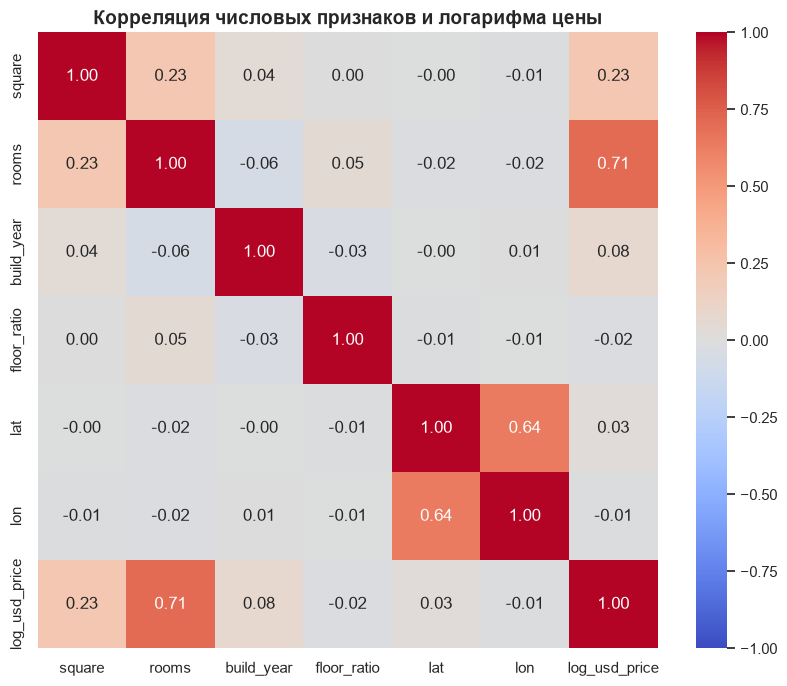

Корреляция признаков с log(usd_price):
log_usd_price    1.000000
rooms            0.706317
square           0.227832
build_year       0.077067
lat              0.030683
lon             -0.013718
floor_ratio     -0.017703
Name: log_usd_price, dtype: float64

Корреляция между square и rooms: 0.2330


In [28]:
# Создаем временный датафрейм для корреляционного анализа
df_eda = X_reg[numeric_cols].copy()
df_eda['log_usd_price'] = np.log1p(y_reg)

# 1.2. Построить тепловую карту корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(df_eda.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Корреляция числовых признаков и логарифма цены', fontsize=14, fontweight='bold')
plt.show()

# Выводим отсортированный список корреляций с таргетом
print("Корреляция признаков с log(usd_price):")
print(df_eda.corr()['log_usd_price'].sort_values(ascending=False))

# 1.3. Оценка корреляции между square и rooms
corr_sq_rm = df_eda['square'].corr(df_eda['rooms'])
print(f"\nКорреляция между square и rooms: {corr_sq_rm:.4f}")
if corr_sq_rm > 0.7:
    print("Внимание: Высокая корреляция! Ridge/Lasso регуляризация будет полезна.")


### Ячейка 4: EDA — KDEplot для логарифма цен

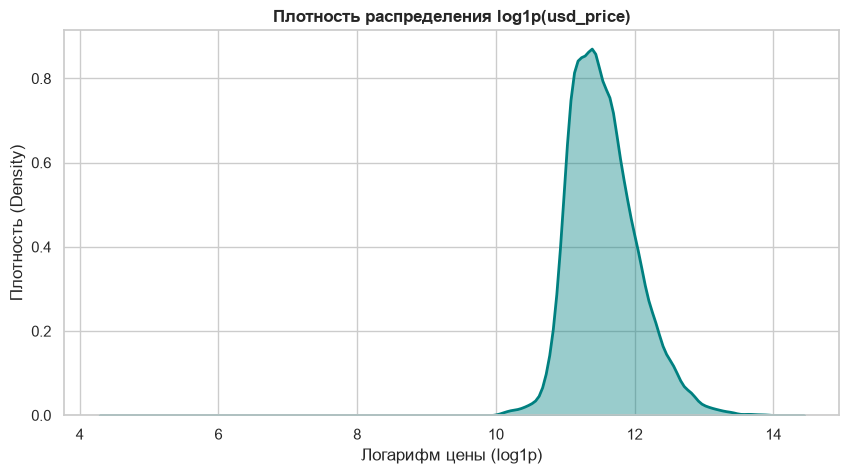

In [29]:
# 1.4. Проверить распределение логарифма цен
plt.figure(figsize=(10, 5))
sns.kdeplot(df_eda['log_usd_price'], fill=True, color='teal', alpha=0.4, linewidth=2)
plt.title('Плотность распределения log1p(usd_price)', fontsize=12, fontweight='bold')
plt.xlabel('Логарифм цены (log1p)')
plt.ylabel('Плотность (Density)')
plt.show()


### Ячейка 5: Подготовка целевой переменной и разделение выборки

In [30]:
# 2.1. Прологарифмировать таргет
y_reg_log = np.log1p(y_reg)

# 4. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg_log, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} строк")
print(f"Test size:  {X_test.shape[0]} строк")


Train size: 9592 строк
Test size:  2398 строк


### Ячейка 6: Обучение Baseline модели (Linear Regression)

In [31]:
# 5. Pipeline для обычной линейной регрессии
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Обучение
lr_pipeline.fit(X_train, y_train)

# Кросс-валидация на train
cv_scores_lr = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring='r2')
print(f"LinearRegression CV R2: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")


LinearRegression CV R2: 0.5676 (+/- 0.0759)


### Ячейка 7: Оптимизация Ridge (L2) через Optuna

In [32]:
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 100, log=True)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha, random_state=42))
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    return scores.mean()

study_ridge = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_ridge.optimize(objective_ridge, n_trials=50)

print(f"Лучшие параметры Ridge: {study_ridge.best_params}")
print(f"Лучший CV R2: {study_ridge.best_value:.4f}")


Лучшие параметры Ridge: {'alpha': 0.00010131239639593315}
Лучший CV R2: 0.5676


### Ячейка 8: Оптимизация Lasso (L1) через Optuna

In [34]:
def objective_lasso(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 10, log=True)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=alpha, random_state=42, max_iter=2000))
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    return scores.mean()

study_lasso = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lasso.optimize(objective_lasso, n_trials=50)

print(f"Лучшие параметры Lasso: {study_lasso.best_params}")
print(f"Лучший CV R2: {study_lasso.best_value:.4f}")


# Лучшие параметры Lasso: {'alpha': 0.0014353067343347437}
# Лучший CV R2: 0.5677

c:\Users\Yoga 7i 1360p\Documents\AI_academy_courses\bish_glory\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.765759e+00, tolerance: 1.819e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Yoga 7i 1360p\Documents\AI_academy_courses\bish_glory\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.949889e+00, tolerance: 1.830e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Yoga 7i 1360p\Documents\AI_academy_courses\bish_glory\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to 

Лучшие параметры Lasso: {'alpha': 0.0014353067343347437}
Лучший CV R2: 0.5677


### Ячейка 9: Оптимизация ElasticNet через Optuna

In [ ]:
def objective_elastic(trial):
    alpha = trial.suggest_float('alpha', 1e-5, 10, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=2000))
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    return scores.mean()

study_elastic = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_elastic.optimize(objective_elastic, n_trials=50)

print(f"Лучшие параметры ElasticNet: {study_elastic.best_params}")
print(f"Лучший CV R2: {study_elastic.best_value:.4f}")

# Лучшие параметры ElasticNet: {'alpha': 0.001498494329792606, 'l1_ratio': 0.9964918574503155}
# Лучший CV R2: 0.5677

c:\Users\Yoga 7i 1360p\Documents\AI_academy_courses\bish_glory\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.935395e+00, tolerance: 1.819e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Yoga 7i 1360p\Documents\AI_academy_courses\bish_glory\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.180301e+00, tolerance: 1.830e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\Yoga 7i 1360p\Documents\AI_academy_courses\bish_glory\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to 

Лучшие параметры ElasticNet: {'alpha': 0.001498494329792606, 'l1_ratio': 0.9964918574503155}
Лучший CV R2: 0.5677


### Ячейка 10: Оптимизация HuberRegressor (Робастная регрессия) через Optuna

In [36]:
def objective_huber(trial):
    epsilon = trial.suggest_float('epsilon', 1.05, 2.0)
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        # Увеличиваем max_iter для стабильной сходимости
        ('model', HuberRegressor(epsilon=epsilon, alpha=alpha, max_iter=2000))
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    return scores.mean()

study_huber = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_huber.optimize(objective_huber, n_trials=50)

print(f"Лучшие параметры HuberRegressor: {study_huber.best_params}")
print(f"Лучший CV R2: {study_huber.best_value:.4f}")


Лучшие параметры HuberRegressor: {'epsilon': 1.9995113273869431, 'alpha': 8.810231189178791e-05}
Лучший CV R2: -3.9986


### Ячейка 11: Кросс-валидация и выбор лучшего алгоритма

In [37]:
# Словарь лучших моделей
best_models = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(**study_ridge.best_params, random_state=42))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(**study_lasso.best_params, random_state=42, max_iter=2000))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(**study_elastic.best_params, random_state=42, max_iter=2000))
    ]),
    'HuberRegressor': Pipeline([
        ('scaler', StandardScaler()),
        ('model', HuberRegressor(**study_huber.best_params, max_iter=2000))
    ])
}

# Оцениваем стабильность CV для каждой модели
results_cv = {}
for name, model_pipeline in best_models.items():
    scores = cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='r2')
    results_cv[name] = scores
    print(f"{name:16} CV R2 Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

# Выбираем модель с максимальным средним R2
best_model_name = max(results_cv, key=lambda k: results_cv[k].mean())
print(f"\nФинальный выбор по кросс-валидации: {best_model_name}")

# Обучаем её на всем X_train
best_pipeline = best_models[best_model_name]
best_pipeline.fit(X_train, y_train)


LinearRegression CV R2 Mean: 0.5676 | Std: 0.0759
Ridge            CV R2 Mean: 0.5676 | Std: 0.0759
Lasso            CV R2 Mean: 0.5677 | Std: 0.0756
ElasticNet       CV R2 Mean: 0.5677 | Std: 0.0756
HuberRegressor   CV R2 Mean: -3.9986 | Std: 8.0721

Финальный выбор по кросс-валидации: Lasso


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](40,)","['lat','lon','square',...,'doc_tech_passport','doc_red_book', 'doc_sale_purchase']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,40
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


### Ячейка 12: Финальная оценка качества на тестовой выборке

In [41]:
# Прогнозы на тесте (в логарифмической шкале)
y_pred_test_log = best_pipeline.predict(X_test)

# Прогнозы и истинные значения в оригинальных долларах (USD)
y_test_usd = np.expm1(y_test)
# Преобразуем массив NumPy в Series с индексами теста
y_pred_test_usd = pd.Series(np.expm1(y_pred_test_log), index=y_test.index)

# Вычисление метрик в лог-шкале
r2_test = r2_score(y_test, y_pred_test_log)
mae_log = mean_absolute_error(y_test, y_pred_test_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_test_log))

# Вычисление метрик в долларах (USD)
mae_usd = mean_absolute_error(y_test_usd, y_pred_test_usd)
rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_test_usd))

print(f"=== Метрики лучшей модели ({best_model_name}) на тесте ===")
print(f"R2 Score:        {r2_test:.4f}")
print("--- В логарифмическом масштабе ---")
print(f"MAE (Log):       {mae_log:.4f}")
print(f"RMSE (Log):      {rmse_log:.4f}")
print("--- В долларах США ($) ---")
print(f"MAE (USD):       ${mae_usd:,.2f}")
print(f"RMSE (USD):      ${rmse_usd:,.2f}")



=== Метрики лучшей модели (Lasso) на тесте ===
R2 Score:        0.6151
--- В логарифмическом масштабе ---
MAE (Log):       0.2249
RMSE (Log):      0.3080
--- В долларах США ($) ---
MAE (USD):       $40,779.80
RMSE (USD):      $458,748.58


### Ячейка 13: Анализ остатков лучшей модели

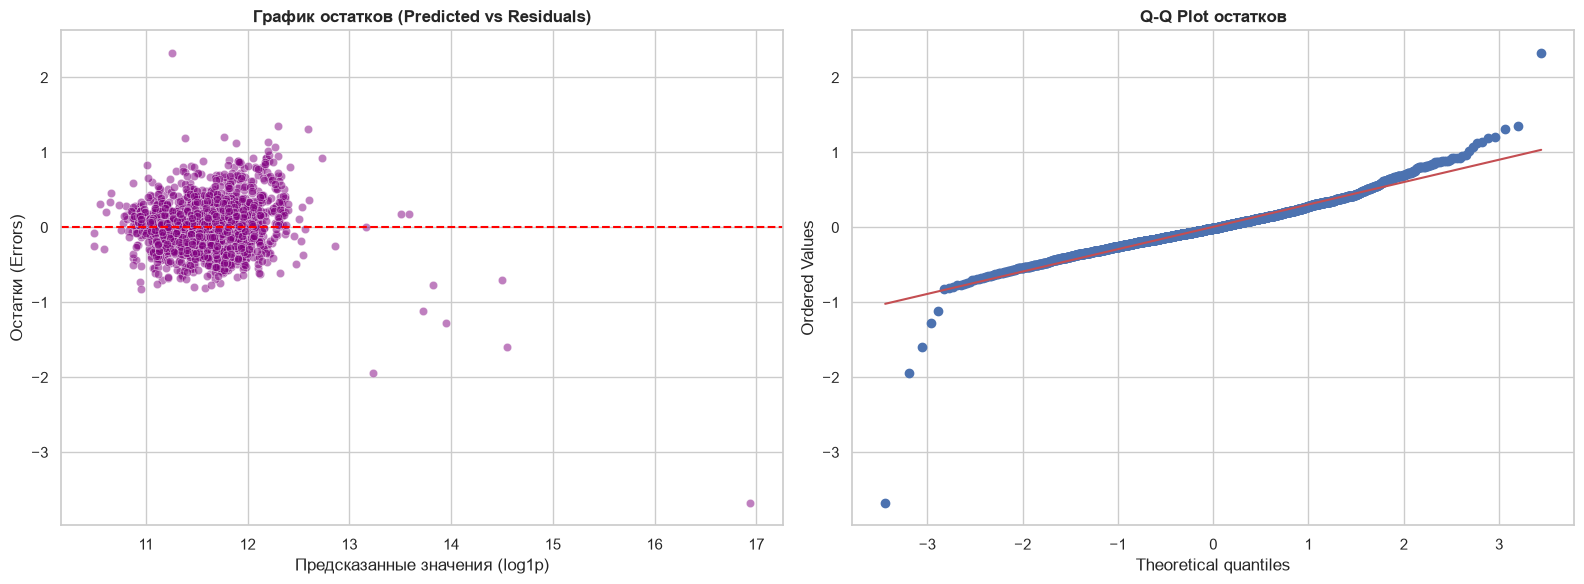

=== Топ-10 аномальных квартир по ошибке предсказания ===
       square  rooms  build_year      lat      lon  True_USD_Price  \
6673    571.0     19        2024  42.8106  74.6242        577099.0   
2110    325.0     11        2023  42.8673  74.5917        425000.0   
4852    320.0     11        2022  42.8250  74.5839        980000.0   
1416    270.0      9        2015  42.8346  74.5633        320000.0   
5052    320.0      5        2022  42.8250  74.5839       1100000.0   
7620     43.0      2        1980  42.8362  74.6201        790003.0   
9806    216.0      4        2024  42.8650  74.6070        849000.0   
4903    260.0      9        2015  42.8345  74.5635        299213.0   
10140   264.0      9        2015  42.8682  74.6019        470000.0   
424     293.0      5        2024  42.8364  74.5827        850000.0   

       Pred_USD_Price  Absolute_Error_USD  
6673     2.275424e+07        2.217714e+07  
2110     2.090670e+06        1.665670e+06  
4852     1.980559e+06        1.000559e+0

In [42]:
residuals = y_test - y_pred_test_log

# Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. График предсказанных значений против остатков
sns.scatterplot(x=y_pred_test_log, y=residuals, ax=axes[0], alpha=0.5, color='purple')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('График остатков (Predicted vs Residuals)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Предсказанные значения (log1p)')
axes[0].set_ylabel('Остатки (Errors)')

# 2. Q-Q plot остатков
st.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot остатков', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 8.3. Топ-10 объектов с наибольшей абсолютной ошибкой в долларах
errors_usd = np.abs(y_test_usd - y_pred_test_usd)
top_10_idx = errors_usd.sort_values(ascending=False).head(10).index

# Извлекаем подробную информацию
anomalies = X_test.loc[top_10_idx].copy()
anomalies['True_USD_Price'] = y_test_usd.loc[top_10_idx]
anomalies['Pred_USD_Price'] = y_pred_test_usd.loc[top_10_idx]
anomalies['Absolute_Error_USD'] = errors_usd.loc[top_10_idx]

print("=== Топ-10 аномальных квартир по ошибке предсказания ===")
# Выводим только основные колонки для читаемости
cols_to_show = ['square', 'rooms', 'build_year', 'lat', 'lon', 'True_USD_Price', 'Pred_USD_Price', 'Absolute_Error_USD']
print(anomalies[cols_to_show])


### Ячейка 14: Визуализация важности признаков (коэффициентов)

C:\Users\Yoga 7i 1360p\AppData\Local\Temp\ipykernel_10080\1283162617.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


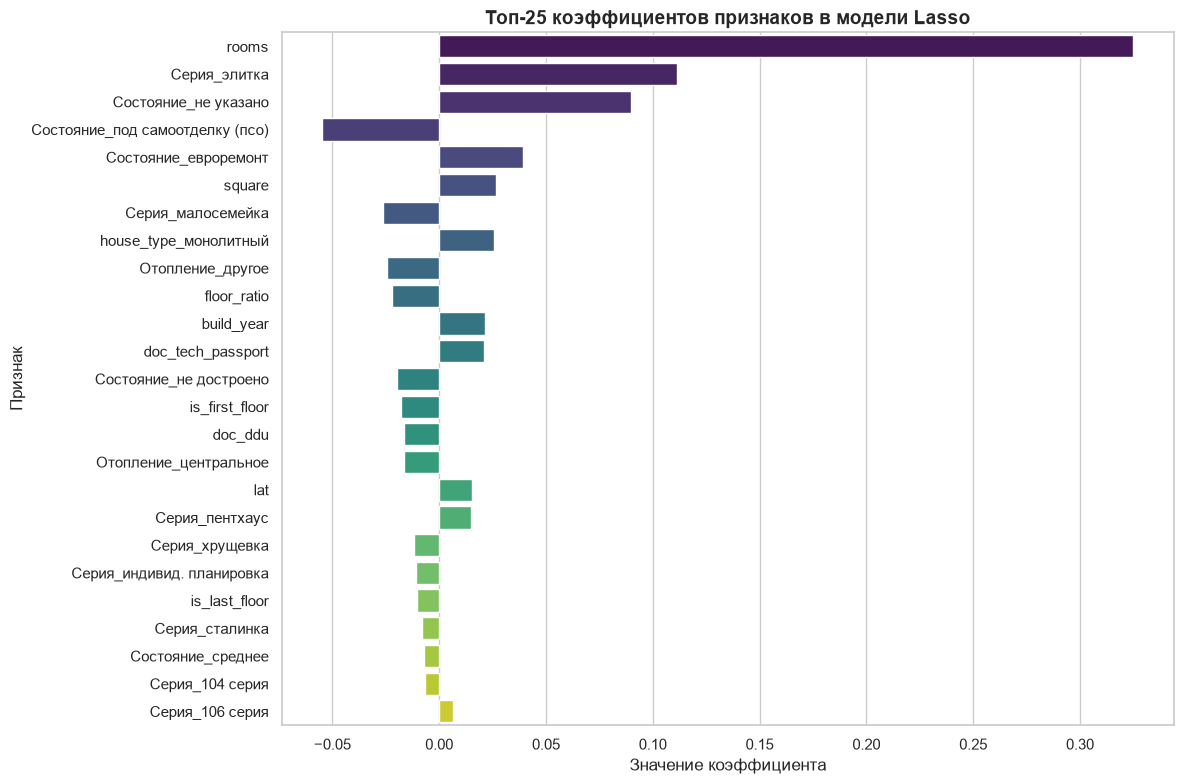

Количество исключенных признаков (коэффициент равен 0): 6
Исключенные признаки:
['Тип предложения_от собственника', 'house_type_кирпичный', 'Серия_105 серия', 'Отопление_не указано', 'Состояние_хорошее', 'doc_red_book']


In [43]:
# Извлекаем модель и коэффициенты
fitted_model = best_pipeline.named_steps['model']
coefficients = fitted_model.coef_

# Если модель HuberRegressor, у нее также есть коэффициенты
# Сопоставляем имена столбцов и их коэффициенты
feature_names = X_reg.columns
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Coef': np.abs(coefficients)
}).sort_values(by='Absolute_Coef', ascending=False)

# Строим график топ-25 признаков по степени влияния
plt.figure(figsize=(12, 8))
sns.barplot(
    data=coef_df.head(25),
    x='Coefficient',
    y='Feature',
    palette='viridis'
)
plt.title(f'Топ-25 коэффициентов признаков в модели {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Значение коэффициента')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# 9.3. Поиск признаков, которые занулились (если использовался Lasso/ElasticNet)
zeroed_features = coef_df[coef_df['Absolute_Coef'] < 1e-7]['Feature'].tolist()
print(f"Количество исключенных признаков (коэффициент равен 0): {len(zeroed_features)}")
if zeroed_features:
    print("Исключенные признаки:")
    print(zeroed_features)


### Ячейка 15: Итоговое сравнение моделей на тестовой выборке

In [44]:
model_comparison = []

for name, model_pipeline in best_models.items():
    # Обучаем
    model_pipeline.fit(X_train, y_train)
    # Предсказываем
    pred_log = model_pipeline.predict(X_test)
    pred_usd = np.expm1(pred_log)
    
    # Метрики
    r2 = r2_score(y_test, pred_log)
    mae_u = mean_absolute_error(y_test_usd, pred_usd)
    rmse_u = np.sqrt(mean_squared_error(y_test_usd, pred_usd))
    
    # Извлекаем лучшие параметры
    if name == 'LinearRegression':
        params = "None"
    elif name == 'Ridge':
        params = f"alpha={study_ridge.best_params['alpha']:.4f}"
    elif name == 'Lasso':
        params = f"alpha={study_lasso.best_params['alpha']:.4f}"
    elif name == 'ElasticNet':
        params = f"alpha={study_elastic.best_params['alpha']:.4f}, l1_ratio={study_elastic.best_params['l1_ratio']:.3f}"
    elif name == 'HuberRegressor':
        params = f"alpha={study_huber.best_params['alpha']:.4f}, epsilon={study_huber.best_params['epsilon']:.3f}"
        
    model_comparison.append({
        'Model': name,
        'Test R2': round(r2, 4),
        'Test MAE (USD)': f"${mae_u:,.2f}",
        'Test RMSE (USD)': f"${rmse_u:,.2f}",
        'Best Hyperparameters': params
    })

comparison_df = pd.DataFrame(model_comparison)
comparison_df.sort_values(by='Test R2', ascending=False)


,Model,Test R2,Test MAE (USD),Test RMSE (USD),Best Hyperparameters
2,Lasso,0.6151,"$40,779.80","$458,748.58",alpha=0.0014
3,ElasticNet,0.6151,"$40,771.37","$458,385.75","alpha=0.0015, l1_ratio=0.996"
0,LinearRegression,0.6144,"$40,994.30","$467,603.16",None
1,Ridge,0.6144,"$40,994.30","$467,603.13",alpha=0.0001
4,HuberRegressor,-4.4424,"$38,132,997,922,978,814,257,790,976.00","$1,867,349,196,686,090,781,119,741,952.00","alpha=0.0001, epsilon=2.000"
